# Wind → wind-farm · M3 — damage (the shared turbine object, **two sub-peril fragility curves**)

**Layer:** M3 (damage) · **shared turbine, forked severity.** The fork at M2 was the *coupling* (how an event
reaches the asset). M3 stays **one asset** — one turbine, one subsystem/capex decomposition, one IEC anchor — but
the **damage a gust does depends on which sub-peril delivered it**, so the one turbine object carries **two
sub-peril fragility curves** (a logical fork inside one notebook, not a folder fork; DD-WN-16).

M3 turns a **3-s gust** into a **damage ratio** `DR(gust, sub-peril)`. Like hail & wildfire, these are
**curated, approximate, anchored** curves (*approximate now, accurate later*) — the **dominant, irreducible
uncertainty** of the whole build, and **greenfield** (the old repo had *no* turbine wind curve — it hacked gust
events onto a generic curve). We **assume reasonable curves** here, structured as a reusable **turbine fragility
object** (the kind that graduates to the shared `infrasure-damage-curves` library — it is an *asset* property, not
a "wind" one), and verify their shape against known answers.

> **M3 is source-agnostic — the gust has no memory of where it came from.** A gust reaches M3 as **just a number
> (m/s)**, whether an SPC-EF tornado or the ASCE strong-wind surface produced it. The source-specific work (two
> different data products → two different gust *severity distributions*) was already resolved **upstream in M0/M1**;
> here the input is one gust and the curve is the **turbine's, not the peril's**. The two curves still differ —
> but on **loading mechanism** (AWN-32), not source. What lets both rails meet on one curve object is the shared
> **3-s-gust** metric (DD-WN-6: the universal observable EF / ASCE / NWS all reconcile to).

> Plan: [`m3_damage.md`](../../../../docs/plans/convective_wind/m3_damage.md) · the two-threshold anchoring:
> [`layer0/01_hazard_definition`](../../layer0/01_hazard_definition.ipynb) · severity background:
> [`hazard_math/03`](../../../../Learning/ML-DL/InfraSure_related/hazard_math/03_severity_event_loss_distributions.md).

## 0 · Intent & scope

**Does:** assume a **subsystem-decomposed, capex-weighted logistic** turbine fragility on the 3-s gust (DD-WN-11),
and give it **two sub-peril parameterizations** on the *one* turbine (DD-WN-16):
- **strong / straight-line wind** — feathered-survival **overload**: reaches only the **aero** subsystems
  (rotor, nacelle, electrical, substation), onset anchored at the **IEC 61400 survival speed** (~60 m/s); below
  survival `DR ≈ 0`, max `DR ≈ 0.65` (it cannot take the tower/foundation).
- **tornado** — rotation **defeats feathering** + vertical / pressure-drop / debris loads the turbine was never
  designed for, and the EF scale is itself **damage-calibrated**: reaches **all** subsystems, with **lower onset
  and steeper** rise → at the *same* gust the tornado does **more** damage (`DR_tornado(v) > DR_strongwind(v)`),
  `DR → 1` at the EF5 ceiling.

Verify `DR(μ) ≈ 0` for both, the tornado-over-strong-wind ordering, the reach caps, `DR_tornado(L) → 1`; emit for M4.

**Does NOT:** calibrate against turbine loss data (greenfield — Low confidence, *approximate now*); compute loss
(M4). The curves are the **honest-about-the-input** half of basics-spot-on; the *math* (M4 sampling) is the
right-about-the-math half.

## Assumptions (this layer)

- **AWN-24** — **anchored subsystem logistic** on 3-s gust; capex-weighted blend (rotor/blades 0.26 · nacelle
  0.21 · tower 0.16 · foundation 0.12 · substation 0.09 · electrical 0.09 · civil 0.07 — old-repo `wind_config`).
- **AWN-9** — strong-wind inflections anchored near the **IEC 61400 survival speed** (class II assumed, Ve50 ≈
  59.5 m/s; confirm per turbine model per site). `DR(μ) ≈ 0`; the curve rises only past survival.
- **AWN-25** — **operational state** (feathered vs operating) noted; V1 uses one curve per sub-peril (survival config).
- **AWN-32** `[OURS]` — **sub-peril damage severity differs** at the *same* gust: tornado loading is **more
  damaging** than straight-line wind (rotation defeats feathering; vertical + atmospheric-pressure-drop + debris
  loads; the EF scale is damage-calibrated). So tornado's per-subsystem onset is **lower** and the curve **steeper**
  — not just *wider reach* (DD-WN-16). Strong wind reaches only **aero** subsystems (max DR ≈ 0.65); tornado all (→1).
- **AWN-26** — **approximate now, accurate later**: Low confidence; the dominant uncertainty; honest label.
- **AWN-31** — strong-wind gusts stay below onset → strong-wind DR ≈ 0 (the M4 known-answer check).

Register: [`assumptions.md`](../../../../docs/plans/convective_wind/assumptions.md) · decision: [`DD-WN-16`](../../../../docs/plans/convective_wind/decisions.md).

## 1 · The anchored-curve concept (two thresholds → `DR(μ) ≈ 0`) and the two-mechanism fork

The turbine is engineered to **feather and survive** up to its **IEC survival speed** (Ve50 ≈ 52–70 m/s). So the
damage curves are **anchored**: `DR(μ=58 mph) ≈ 0` (most "severe wind" barely scratches it). We build per
subsystem (each with its own anchor `x0` and steepness `k`), then **capex-weight-blend** — because subsystems fail
at different gusts (blades first; tower/foundation only in violent tornado), and the loss is the value-weighted sum.

**Why two curves, not one with two reaches:** straight-line wind and a tornado at the *same* 3-s gust are not the
same load. Straight-line wind lets the turbine **feather** (blades pitch edge-on) — damage needs a gust that
*overwhelms the survival design*. A tornado's **rotation defeats feathering**, and adds vertical, pressure-drop and
debris loads the design never anticipated; the EF rating is itself read **from the damage**. So the tornado curve
has a **lower onset and steeper rise** on every subsystem — `DR_tornado(v) > DR_strongwind(v)` — and reaches the
tower/foundation too. One turbine object (shared capex split / IEC anchor), **two sub-peril fragility maps**.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})
MS = 0.44704                                                   # mph → m/s
MU_W, MU_T, L = 25.92, 29.0, 113.0                            # event thresholds + bound (m/s)
IEC_VE50 = (52.5, 70.0)                                        # IEC survival band (class III→I), m/s
EF_BANDS = {0: (29, 38), 1: (38, 49), 2: (50, 60), 3: (61, 74), 4: (74, 89), 5: (90, 113)}   # m/s

# One turbine — shared capex split (old-repo `wind_config`; AWN-24).
CAPEX = {
    "rotor_blades": 0.26, "nacelle_drivetrain": 0.21, "tower": 0.16, "foundation": 0.12,
    "substation": 0.09, "electrical": 0.09, "civil": 0.07,
}
# Per-sub-peril fragility {subsystem: (inflection x0 [m/s], steepness k)} — the LOADING MECHANISM differs (AWN-32):
#   strong_wind = feathered-survival OVERLOAD → aero subsystems only, onset at IEC survival (~60 m/s).
#   tornado     = rotation defeats feathering + vertical / pressure-drop / debris; EF is damage-calibrated →
#                 ALL subsystems, onset ~8-12 m/s LOWER + steeper (more damage at the SAME gust).  APPROXIMATE (AWN-26).
FRAG = {
    "strong_wind": {"rotor_blades": (60, 0.30), "nacelle_drivetrain": (66, 0.28),
                    "substation": (62, 0.28), "electrical": (64, 0.28)},
    "tornado":     {"rotor_blades": (52, 0.25), "nacelle_drivetrain": (58, 0.24), "tower": (66, 0.22),
                    "foundation": (80, 0.20), "substation": (54, 0.24), "electrical": (56, 0.24),
                    "civil": (62, 0.22)},
}
SUBPERILS = ("tornado", "strong_wind")
AERO = set(FRAG["strong_wind"])                                # strong-wind reach = the aero subsystems


def dr(v, subperil):
    """Capex-weighted blended damage ratio at 3-s gust v (m/s) for a sub-peril ('tornado' | 'strong_wind')."""
    v = np.asarray(v, float)
    return sum(CAPEX[s] / (1 + np.exp(-k * (v - x0))) for s, (x0, k) in FRAG[subperil].items())


def _repo_root() -> Path:
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "AGENTS.md").exists():
            return p
    raise FileNotFoundError("repo root (AGENTS.md) not found")


ROOT = _repo_root()
DATA_DIR = ROOT / "data" / "convective_wind"
print(f"repo root: {ROOT}")
print(f"capex weights sum = {sum(CAPEX.values()):.3f} | aero (strong-wind) reach weight = {sum(CAPEX[s] for s in AERO):.2f}")
print(f"sub-perils: {SUBPERILS} (one turbine, two fragility maps — DD-WN-16)")

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
capex weights sum = 1.000 | aero (strong-wind) reach weight = 0.65
sub-perils: ('tornado', 'strong_wind') (one turbine, two fragility maps — DD-WN-16)


## 2 · The two curves — DR at key gusts (both anchored; tornado ≥ strong wind everywhere)

In [2]:
rows = []
for mph in [58, 65, 85, 111, 135, 165, 200, 253]:
    v = mph * MS
    ef = next((f"EF{e}" for e, (lo, hi) in EF_BANDS.items() if lo <= v < hi), "—")
    rows.append({"gust_mph": mph, "gust_ms": round(v, 1), "EF~": ef,
                 "DR_tornado": round(float(dr(v, "tornado")), 4),
                 "DR_strongwind": round(float(dr(v, "strong_wind")), 4)})
print(pd.DataFrame(rows).to_string(index=False))
print(f"\nAnchored: DR(μ=58mph)≈0 for both ✓ · tornado rises earlier/steeper (lower onset) · DR_tornado→1 at L.")
print("Strong wind capped at the aero weight (~0.65) — it cannot take the tower/foundation; only tornado reaches DR=1.")
print("At every gust DR_tornado ≥ DR_strongwind — the mechanism difference (AWN-32), not just wider reach.")

 gust_mph  gust_ms EF~  DR_tornado  DR_strongwind
       58     25.9   —      0.0007         0.0000
       65     29.1 EF0      0.0015         0.0000
       85     38.0 EF0      0.0131         0.0006
      111     49.6   —      0.1654         0.0175
      135     60.4   —      0.5725         0.2312
      165     73.8 EF3      0.8695         0.6157
      200     89.4   —      0.9829         0.6495
      253    113.1   —      0.9998         0.6500

Anchored: DR(μ=58mph)≈0 for both ✓ · tornado rises earlier/steeper (lower onset) · DR_tornado→1 at L.
Strong wind capped at the aero weight (~0.65) — it cannot take the tower/foundation; only tornado reaches DR=1.
At every gust DR_tornado ≥ DR_strongwind — the mechanism difference (AWN-32), not just wider reach.


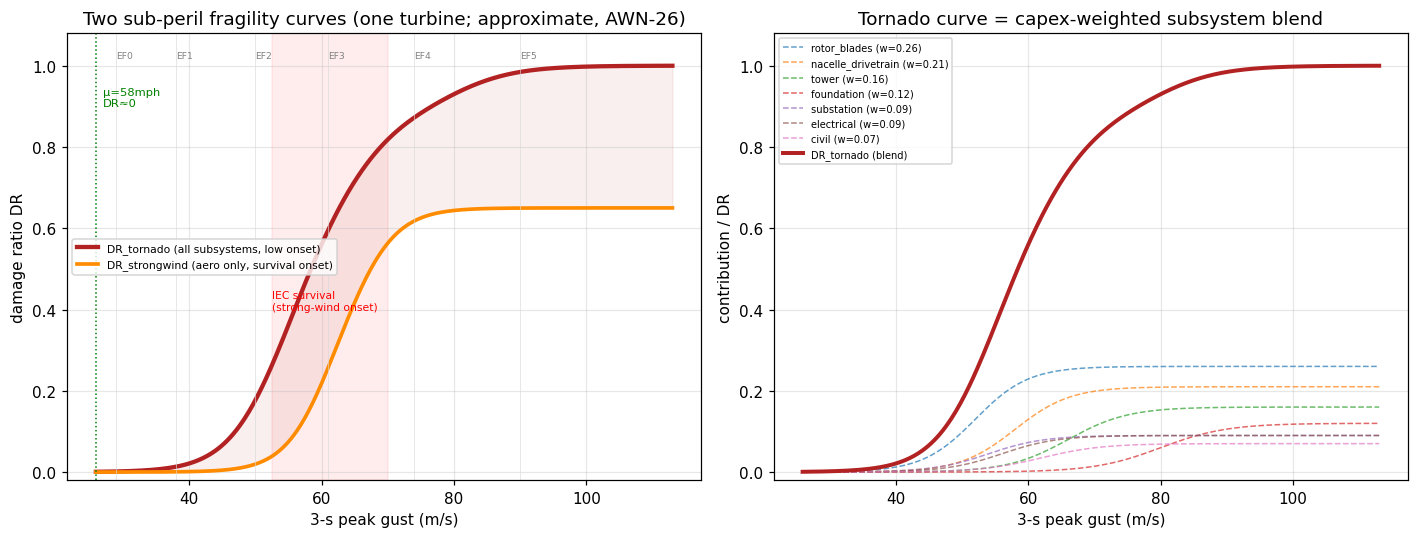

Takeaway: both curves are ≈0 across the bulk of the catalog (μ→survival). Tornado (red) onsets earlier, rises
steeper and reaches DR=1 (takes tower+foundation); strong wind (orange) only past survival, plateaus at ~0.65.


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
vv = np.linspace(MU_W, L, 400)
# (a) the two blended sub-peril curves
ax = axes[0]
ax.plot(vv, dr(vv, "tornado"), lw=2.8, color="firebrick", label="DR_tornado (all subsystems, low onset)")
ax.plot(vv, dr(vv, "strong_wind"), lw=2.4, color="darkorange", label="DR_strongwind (aero only, survival onset)")
ax.fill_between(vv, dr(vv, "strong_wind"), dr(vv, "tornado"), color="firebrick", alpha=0.07)
ax.axvline(MU_W, color="green", ls=":", lw=1); ax.text(MU_W + 1, 0.9, "μ=58mph\nDR≈0", color="green", fontsize=7.5)
ax.axvspan(*IEC_VE50, color="red", alpha=0.07); ax.text(IEC_VE50[0], 0.4, "IEC survival\n(strong-wind onset)", color="red", fontsize=7)
for e, (lo, hi) in EF_BANDS.items():
    ax.axvline(lo, color="0.85", lw=0.4); ax.text(lo, 1.02, f"EF{e}", fontsize=6, color="0.5")
ax.set_xlabel("3-s peak gust (m/s)"); ax.set_ylabel("damage ratio DR"); ax.set_ylim(-0.02, 1.08)
ax.set_title("Two sub-peril fragility curves (one turbine; approximate, AWN-26)"); ax.legend(fontsize=7, loc="center left")
# (b) the subsystem decomposition (tornado, the full-reach case)
ax = axes[1]
for s, (x0, k) in FRAG["tornado"].items():
    ax.plot(vv, [CAPEX[s] / (1 + np.exp(-k * (v - x0))) for v in vv], lw=1.0, alpha=0.7, ls="--",
            label=f"{s} (w={CAPEX[s]})")
ax.plot(vv, dr(vv, "tornado"), lw=2.6, color="firebrick", label="DR_tornado (blend)")
ax.set_xlabel("3-s peak gust (m/s)"); ax.set_ylabel("contribution / DR"); ax.set_ylim(-0.02, 1.08)
ax.set_title("Tornado curve = capex-weighted subsystem blend"); ax.legend(fontsize=6.5, loc="upper left")
plt.tight_layout(); plt.show()
print("Takeaway: both curves are ≈0 across the bulk of the catalog (μ→survival). Tornado (red) onsets earlier, rises")
print("steeper and reaches DR=1 (takes tower+foundation); strong wind (orange) only past survival, plateaus at ~0.65.")

## 3 · Strong-wind ≈ 0 vs tornado-damaging — the curves × each severity

In [4]:
rng = np.random.default_rng(0)
# strong-wind severity (Gumbel/exp, μ=25.9, σ≈3.58 Traverse) — gusts rarely reach onset
g_sw = MU_W + rng.exponential(3.58, 2_000_000); g_sw = g_sw[g_sw <= L]
e_dr_sw = float(dr(g_sw, "strong_wind").mean())
print(f"STRONG WIND  E[DR|event] = {e_dr_sw:.6f}  → with λ≈0.9/yr, EAL ≈ {0.9*e_dr_sw*100:.4f}% of TIV/yr  → ≈ 0 ✓")
print("  (gusts ~26–35 m/s dominate, far below survival; even the rare ~50 m/s tail gives DR≈2%) → the M4 check.")
print("\nTORNADO  DR at EF-band midpoints (the damaging tail) vs strong wind at the same gust:")
for e, (lo, hi) in EF_BANDS.items():
    mid = (lo + hi) / 2
    print(f"  EF{e} (~{mid:.0f} m/s = {mid/MS:.0f} mph): DR_tornado = {float(dr(mid,'tornado')):.3f}   (strong wind = {float(dr(mid,'strong_wind')):.3f})")
print("→ tornado EF2 already bites (~36%), EF4 major (~95%), EF5 near-total — the catastrophic single-asset tail.")

STRONG WIND  E[DR|event] = 0.000225  → with λ≈0.9/yr, EAL ≈ 0.0203% of TIV/yr  → ≈ 0 ✓
  (gusts ~26–35 m/s dominate, far below survival; even the rare ~50 m/s tail gives DR≈2%) → the M4 check.

TORNADO  DR at EF-band midpoints (the damaging tail) vs strong wind at the same gust:
  EF0 (~34 m/s = 75 mph): DR_tornado = 0.004   (strong wind = 0.000)
  EF1 (~44 m/s = 97 mph): DR_tornado = 0.047   (strong wind = 0.003)
  EF2 (~55 m/s = 123 mph): DR_tornado = 0.362   (strong wind = 0.074)
  EF3 (~68 m/s = 151 mph): DR_tornado = 0.773   (strong wind = 0.501)
  EF4 (~82 m/s = 182 mph): DR_tornado = 0.942   (strong wind = 0.646)
  EF5 (~102 m/s = 227 mph): DR_tornado = 0.998   (strong wind = 0.650)
→ tornado EF2 already bites (~36%), EF4 major (~95%), EF5 near-total — the catastrophic single-asset tail.


## 4 · Known-answer checks (basics spot-on — the curves' shape & ordering)

In [5]:
grid = np.linspace(MU_W, L, 400)
onset = lambda sp: float(grid[np.argmax(dr(grid, sp) >= 0.05)])   # first gust with DR ≥ 5%
checks = {
    "capex weights sum to 1": abs(sum(CAPEX.values()) - 1.0) < 1e-9,
    "DR_strongwind(μ=58mph) ≈ 0": float(dr(MU_W, "strong_wind")) < 0.01,
    "DR_tornado(μ_tornado=EF0 onset) ≈ 0": float(dr(MU_T, "tornado")) < 0.01,
    "DR_tornado ≥ DR_strongwind at every gust (AWN-32 mechanism)": bool(np.all(dr(grid, "tornado") >= dr(grid, "strong_wind") - 1e-9)),
    "tornado onset (DR=5%) below strong-wind onset": onset("tornado") < onset("strong_wind"),
    "both curves monotone increasing in gust": all(bool(np.all(np.diff(dr(grid, sp)) >= -1e-9)) for sp in SUBPERILS),
    "DR_tornado(L) → 1 (total loss at EF5 ceiling)": float(dr(L, "tornado")) > 0.95,
    "DR_strongwind capped < DR_tornado (no tower/foundation)": float(dr(L, "strong_wind")) < float(dr(L, "tornado")),
    "DR_strongwind(L) ≈ aero weight (~0.65)": abs(float(dr(L, "strong_wind")) - sum(CAPEX[s] for s in AERO)) < 0.02,
    "DR ∈ [0,1] for both": all(bool((dr(grid, sp) <= 1.0).all() and (dr(grid, sp) >= 0).all()) for sp in SUBPERILS),
}
for k, v in checks.items():
    print(f"  [{'PASS' if v else 'FAIL'}] {k}")
assert all(checks.values()), "M3 curve failed a known-answer check"
print(f"\nonset (DR≥5%): tornado ≈ {onset('tornado'):.0f} m/s ({onset('tornado')/MS:.0f} mph) vs strong wind ≈ {onset('strong_wind'):.0f} m/s ({onset('strong_wind')/MS:.0f} mph)")
print("all known-answer checks PASS — both curves correctly anchored, tornado correctly the more-severe mechanism.")

  [PASS] capex weights sum to 1
  [PASS] DR_strongwind(μ=58mph) ≈ 0
  [PASS] DR_tornado(μ_tornado=EF0 onset) ≈ 0
  [PASS] DR_tornado ≥ DR_strongwind at every gust (AWN-32 mechanism)
  [PASS] tornado onset (DR=5%) below strong-wind onset
  [PASS] both curves monotone increasing in gust
  [PASS] DR_tornado(L) → 1 (total loss at EF5 ceiling)
  [PASS] DR_strongwind capped < DR_tornado (no tower/foundation)
  [PASS] DR_strongwind(L) ≈ aero weight (~0.65)
  [PASS] DR ∈ [0,1] for both

onset (DR≥5%): tornado ≈ 44 m/s (98 mph) vs strong wind ≈ 54 m/s (120 mph)
all known-answer checks PASS — both curves correctly anchored, tornado correctly the more-severe mechanism.


## 5 · Emit the curves (→ M4)

In [6]:
v_grid = np.round(np.arange(MU_W, L + 0.001, 0.5), 2)
lut = pd.DataFrame({"gust_ms": v_grid,
                    "dr_tornado": np.round(dr(v_grid, "tornado"), 6),
                    "dr_strongwind": np.round(dr(v_grid, "strong_wind"), 6)})
lut.to_parquet(DATA_DIR / "wind_m3_damage_curve_lut.parquet", index=False)
manifest = {
    "layer": "M3", "source": "m3_damage/01_damage", "peril": "wind", "scope": "shared turbine, two sub-peril curves",
    "curve": "anchored subsystem logistic on 3-s gust (capex-weighted); DR(v)=Σ wᵢ/(1+exp(-kᵢ(v-x0ᵢ))) per sub-peril",
    "capex_weights": CAPEX,
    "fragility_per_subperil": {sp: {s: {"x0_ms": x0, "k": k} for s, (x0, k) in FRAG[sp].items()} for sp in SUBPERILS},
    "aero_reach": sorted(AERO), "aero_weight": round(sum(CAPEX[s] for s in AERO), 3),
    "mechanism_rule": ("strong wind = feathered-survival overload → aero subsystems, onset at IEC survival (max DR≈0.65); "
                       "tornado = rotation defeats feathering + vertical/pressure/debris, EF damage-calibrated → all "
                       "subsystems, lower onset + steeper (DR→1). DR_tornado(v) > DR_strongwind(v) at every gust (AWN-32)."),
    "iec_class_assumed": "II (Ve50≈59.5 m/s) — confirm per turbine model per site (AWN-9)",
    "thresholds_ms": {"mu_strong_wind": MU_W, "mu_tornado": MU_T, "L": L},
    "confidence": "Low (greenfield, approximate now / accurate later — AWN-26); the dominant irreducible uncertainty",
    "known_answer_for_M4": "strong-wind EAL must verify ≈0 (gusts below onset); else the curve is mis-anchored",
    "lut": "wind_m3_damage_curve_lut.parquet (gust_ms → dr_tornado, dr_strongwind)",
}
(DATA_DIR / "wind_m3_damage_manifest.json").write_text(json.dumps(manifest, indent=2, default=str))
print(f"wrote {(DATA_DIR/'wind_m3_damage_curve_lut.parquet').relative_to(ROOT)} ({len(lut)} rows) + manifest")

wrote data/convective_wind/wind_m3_damage_curve_lut.parquet (175 rows) + manifest


### Findings & open questions (→ M4)

- **One turbine, two sub-peril curves** (DD-WN-16): both anchored (DR(μ)≈0, rise near/below IEC survival, the
  tornado curve →1 at L). The difference is **mechanism, not just reach** — `DR_tornado(v) > DR_strongwind(v)` at
  *every* gust (tornado defeats feathering + adds vertical/pressure/debris loads; AWN-32), and tornado reaches all
  subsystems while strong wind caps at the **aero** weight (~0.65).
- **Strong-wind DR ≈ 0** (E[DR|event]≈2e-4 → EAL ≈0.02% of TIV) — gusts stay below onset; this is the **M4
  known-answer check** (if strong-wind EAL comes out large, the curve is mis-anchored). Strong wind's real impact is
  the **deferred disruption/degradation track** (AWN-31), not this curve.
- **Tornado is the damaging tail** — DR_tornado EF2 ~36%, EF4 ~95%, EF5 near-total (steeper / earlier than before,
  per the mechanism) — the catastrophic single-asset loss.
- **Approximate (Low confidence, AWN-26)** — the dominant uncertainty; the IEC class is assumed (II); calibrated
  curves from the `infrasure-damage-curves` library are the deferred upgrade.
- **(M4)** sample each sub-peril's events through **its own** curve → one annual-loss distribution per site;
  EAL/VaR/PML/TVaR off the joint, % of TIV; strong wind ≈0, tornado the driver; TVaR for the sparse tornado tail.